# LAB 6 : Recurrent Neural Networks

Name : Sabyasachi Ghosal

Roll Number : 24PHDDI05

Referrence Material :

1. https://github.com/pangolulu/rnn-from-scratch
2. https://www.analyticsvidhya.com/blog/2019/01/fundamentals-deep-learning-recurrent-neural-networks-scratch-python/


#**Problem 1** : Next Token Prediction in a Sequence

Observation to be demonstrated:

1. Generate the data required
2. Represent tokens as indices using dictionaries
3. Convert the tokens into vectors using One hot encoding
4. Implement Recurrent Neural Network to solve the Next token prediction problem

##Write down the Objectives, Hypothesis and Experimental description for the above problem



## Objectives
The objectives include the following
- Training an RNN model to predict the next token in a sequence

## Hypothesis
These are the hypothesis
- RNN can handle sequential information
- It can capture temporal relations between tokens

## Experimental Description
- A dataset is created with random sequence of 'a' and 'b' consecuteively followed by EOS
- The output labels is converted into 1-hot encoders
- An RNN is trained on the data set
- The results are analyses for train, validation and test set.


## Programming :


1. **Representing tokens or text**

In previous labs we mainly considered data $x \in \mathrm{R}^d$, where $d$ is the feature space dimension.
With time sequences our data can be represented as $x \in \mathrm{R}^{t \, \times \, d}$, where $t$ is the sequence length.
This emphasises sequence dependence and that the samples along the sequence are not independent and identically distributed (i.i.d.).
We will model functions as $\mathrm{R}^{t \, \times \, d} \rightarrow \mathrm{R}^c$, where $c$ is the amount of classes in the output.

There are several ways to represent sequences. With text, the challenge is how to represent a word as a feature vector in $d$ dimensions, as we are required to represent text with decimal numbers in order to apply neural networks to it.

In this exercise we will use a simple one-hot encoding but for categorical variables that can take on many values (e.g. words in the English language) this may be infeasible. For such scenarios, you can project the encodings into a smaller space by use of embeddings.

2. **One-hot encoding over vocabulary**

One way to represent a fixed amount of words is by making a one-hot encoded vector, which consists of 0s in all cells with the exception of a single 1 in a cell used uniquely to identify each word.

| vocabulary    | one-hot encoded vector   |
| ------------- |--------------------------|
| Paris         | $= [1, 0, 0, \ldots, 0]$ |
| Rome          | $= [0, 1, 0, \ldots, 0]$ |
| Copenhagen    | $= [0, 0, 1, \ldots, 0]$ |

Representing a large vocabulary with one-hot encodings often becomes inefficient because of the size of each sparse vector.
To overcome this challenge it is common practice to truncate the vocabulary to contain the $k$ most used words and represent the rest with a special symbol, $\mathtt{UNK}$, to define unknown/unimportant words.
This often causes entities such as names to be represented with $\mathtt{UNK}$ because they are rare.

Consider the following text
> I love the corny jokes in Spielberg's new movie.

where an example result would be similar to
> I love the corny jokes in $\mathtt{UNK}$'s new movie.

In [1]:
# Import 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.rnn as rnn_utils
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt

## Generating a dataset

For this exercise we will create a simple dataset that we can learn from. We generate sequences of the form:

`a a a a b b b b EOS`, `a a b b EOS`, `a a a a a b b b b b EOS`

where `EOS` is a special character denoting the end of a sequence. The task is to predict the next token $t_n$, i.e. `a`, `b`, `EOS` or the unknown token `UNK` given the sequence of tokens $\{ t_{1}, t_{2}, \dots , t_{n-1}\}$ and we are to process sequences in a sequential manner. As such, the network will need to learn that e.g. 5 `b`s and an `EOS` token will occur following 5 `a`s.

In [2]:
import numpy as np

# Set seed such that we always get the same dataset
np.random.seed(42)

def generate_dataset(num_sequences=100):
    """
    Generates a number of sequences as our dataset.

    Args:
     `num_sequences`: the number of sequences to be generated.

    Returns a list of sequences.
    """
    samples = []

    for _ in range(num_sequences):
        num_tokens = np.random.randint(1, 10)
        sample = ['a'] * num_tokens + ['b'] * num_tokens + ['EOS']
        samples.append(sample)

    return samples


sequences = generate_dataset()

print('A single sample from the generated dataset:')
print(sequences[0])

A single sample from the generated dataset:
['a', 'a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']


## Representing tokens as indices

To build a one-hot encoding, we need to assign each possible word in our vocabulary an index. We do that by creating two dictionaries: one that allows us to go from a given word to its corresponding index in our vocabulary, and one for the reverse direction. Let's call them `word_to_idx` and `idx_to_word`. The keyword `num_words` specifies the maximum size of our vocabulary. If we try to access a word that does not exist in our vocabulary, it is automatically replaced by the `UNK` token or its corresponding index.

In [3]:
from collections import defaultdict

def sequences_to_dicts(sequences):
    """
    Creates word_to_idx and idx_to_word dictionaries for a list of sequences.
    """
    # A bit of Python-magic to flatten a nested list
    flatten = lambda l: [item for sublist in l for item in sublist]

    # Flatten the dataset
    all_words = flatten(sequences)

    # Count number of word occurences
    word_count = defaultdict(int)
    for word in flatten(sequences):
        word_count[word] += 1

    # Sort by frequency
    word_count = sorted(list(word_count.items()), key=lambda l: -l[1])

    # Create a list of all unique words
    unique_words = [item[0] for item in word_count]

    # Add UNK token to list of words
    unique_words.append('UNK')

    # Count number of sequences and number of unique words
    num_sentences, vocab_size = len(sequences), len(unique_words)

    # Create dictionaries so that we can go from word to index and back
    # If a word is not in our vocabulary, we assign it to token 'UNK'
    word_to_idx = defaultdict(lambda: num_words)
    idx_to_word = defaultdict(lambda: 'UNK')

    # Fill dictionaries
    for idx, word in enumerate(unique_words):
        # YOUR CODE HERE!
        word_to_idx[word] = idx
        idx_to_word[idx] = word

    return word_to_idx, idx_to_word, num_sentences, vocab_size


word_to_idx, idx_to_word, num_sequences, vocab_size = sequences_to_dicts(sequences)

print(f'We have {num_sequences} sentences and {len(word_to_idx)} unique tokens in our dataset (including UNK).\n')
print('The index of \'b\' is', word_to_idx['b'])
print(f'The word corresponding to index 1 is \'{idx_to_word[1]}\'')

We have 100 sentences and 4 unique tokens in our dataset (including UNK).

The index of 'b' is 1
The word corresponding to index 1 is 'b'


## One-hot encodings

We now create a simple function that returns the one-hot encoded representation of a given index of a word in our vocabulary. Notice that the shape of the one-hot encoding is equal to the vocabulary (which can be huge!). Additionally, we define a function to automatically one-hot encode a sentence.

In [4]:
def one_hot_encode(idx, vocab_size):
    """
    One-hot encodes a single word given its index and the size of the vocabulary.

    Args:
     `idx`: the index of the given word
     `vocab_size`: the size of the vocabulary

    Returns a 1-D numpy array of length `vocab_size`.
    """
    # Initialize the encoded array
    one_hot = np.zeros(vocab_size)

    # Set the appropriate element to one
    one_hot[idx] = 1.0

    return one_hot


def one_hot_encode_sequence(sequence, vocab_size):
    """
    One-hot encodes a sequence of words given a fixed vocabulary size.

    Args:
     `sentence`: a list of words to encode
     `vocab_size`: the size of the vocabulary

    Returns a 3-D numpy array of shape (num words, vocab size, 1).
    """
    # Encode each word in the sentence
    encoding = np.array([one_hot_encode(word_to_idx[word], vocab_size) for word in sequence])

    # Reshape encoding s.t. it has shape (num words, vocab size, 1)
    encoding = encoding.reshape(encoding.shape[0], encoding.shape[1], 1)

    return encoding


test_word = one_hot_encode(word_to_idx['a'], vocab_size)
print(f'Our one-hot encoding of \'a\' has shape {test_word.reshape([4,1]).shape}.')
print(test_word)

test_sentence = one_hot_encode_sequence(['b', 'EOS'], vocab_size)
print(f'Our one-hot encoding of \'a b\' has shape {test_sentence.shape}.')
print(test_sentence)

Our one-hot encoding of 'a' has shape (4, 1).
[1. 0. 0. 0.]
Our one-hot encoding of 'a b' has shape (2, 4, 1).
[[[0.]
  [1.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [1.]
  [0.]]]


## Creating Dataset

To build our dataset, we need to create inputs and targets for each sequences and partition sentences into training and test sets. 80% and 20% is a common distribution, but mind you that this largely depends on the size of the dataset. **Since we are doing next-word predictions, our target sequence is simply the input sequence shifted by one word.**

In [5]:
from torch.utils import data
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.rnn as rnn_utils

class Dataset(data.Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        # Return the size of the dataset
        return len(self.targets)

    def __getitem__(self, index):
        # Retrieve inputs and targets at the given index
        X = self.inputs[index]
        y = self.targets[index]

        return X, y


def create_datasets(sequences, dataset_class, p_train=0.8, p_val=0.1, p_test=0.1):
    # Define partition sizes
    num_train = int(len(sequences)*p_train)
    num_val = int(len(sequences)*p_val)
    num_test = int(len(sequences)*p_test)

    # Split sequences into partitions
    sequences_train = sequences[:num_train]
    sequences_val = sequences[num_train:num_train+num_val]
    sequences_test = sequences[-num_test:]

    def get_inputs_targets_from_sequences(sequences):
        # Define empty lists
        inputs, targets = [], []
        
        # Append inputs and targets s.t. both lists contain L-1 words of a sentence of length L
        # but targets are shifted right by one so that we can predict the next word
        for sequence in sequences:
            ##### ----------------------------------->
            # One-hot encode the entire sequence
            encoded_sequence = one_hot_encode_sequence(sequence, vocab_size)
            # print("Sequence " ,sequence)
            # print(encoded_sequence)        
            # Split into inputs and targets
            inputs.append(encoded_sequence[:-1])
            targets.append(encoded_sequence[1:])
        
        
        # Pad sequences for uniform length across batches
        inputs_padded = rnn_utils.pad_sequence([torch.tensor(i, dtype=torch.float) for i in inputs], batch_first=True)
        targets_padded = rnn_utils.pad_sequence([torch.tensor(t, dtype=torch.float) for t in targets], batch_first=True)

        return inputs_padded, targets_padded


    # Get inputs and targets for each partition
    inputs_train, targets_train = get_inputs_targets_from_sequences(sequences_train)
    inputs_val, targets_val = get_inputs_targets_from_sequences(sequences_val)
    inputs_test, targets_test = get_inputs_targets_from_sequences(sequences_test)

    # Create datasets
    training_set = dataset_class(inputs_train, targets_train)
    validation_set = dataset_class(inputs_val, targets_val)
    test_set = dataset_class(inputs_test, targets_test)

    return training_set, validation_set, test_set


training_set, validation_set, test_set = create_datasets(sequences, Dataset)
train_loader = DataLoader(training_set, batch_size=2, shuffle=True)
val_loader = DataLoader(validation_set, batch_size=2, shuffle=False)
test_loader = DataLoader(test_set, batch_size=2, shuffle=False)

print(f'We have {len(training_set)} samples in the training set.')
print(f'We have {len(validation_set)} samples in the validation set.')
print(f'We have {len(test_set)} samples in the test set.')

We have 80 samples in the training set.
We have 10 samples in the validation set.
We have 10 samples in the test set.


## Implementation of RNN :

A recurrent neural network (RNN) is a type of neural network that has been succesful in modelling sequential data, e.g. language, speech, protein sequences, etc.

A RNN performs its computations in a cyclic manner, where the same computation is applied to every sample of a given sequence.
The idea is that the network should be able to use the previous computations as some form of memory and apply this to future computations.
An image may best explain how this is to be understood,

![rnn-unroll image](https://github.com/DeepLearningDTU/02456-deep-learning-with-PyTorch/blob/master/static_files/rnn-unfold.png?raw=1)


where it the network contains the following elements:

- $x$ is the input sequence of samples,
- $U$ is a weight matrix applied to the given input sample,
- $V$ is a weight matrix used for the recurrent computation in order to pass memory along the sequence,
- $W$ is a weight matrix used to compute the output of the every timestep (given that every timestep requires an output),
- $h$ is the hidden state (the network's memory) for a given time step, and
- $o$ is the resulting output.

When the network is unrolled as shown, it is easier to refer to a timestep, $t$.
We have the following computations through the network:

- $h_t = f(U\,{x_t} + V\,{h_{t-1}})$, where $f$ usually is an activation function, e.g. $\mathrm{tanh}$.
- $o_t = \mathrm{softmax}(W\,{h_t})$


**Steps :**

  1. Implement Forward Pass, Backward Pass and Optimisation
  2. Write the training loop
  3. Take care of the exploding gradient problem by clipping the gradients

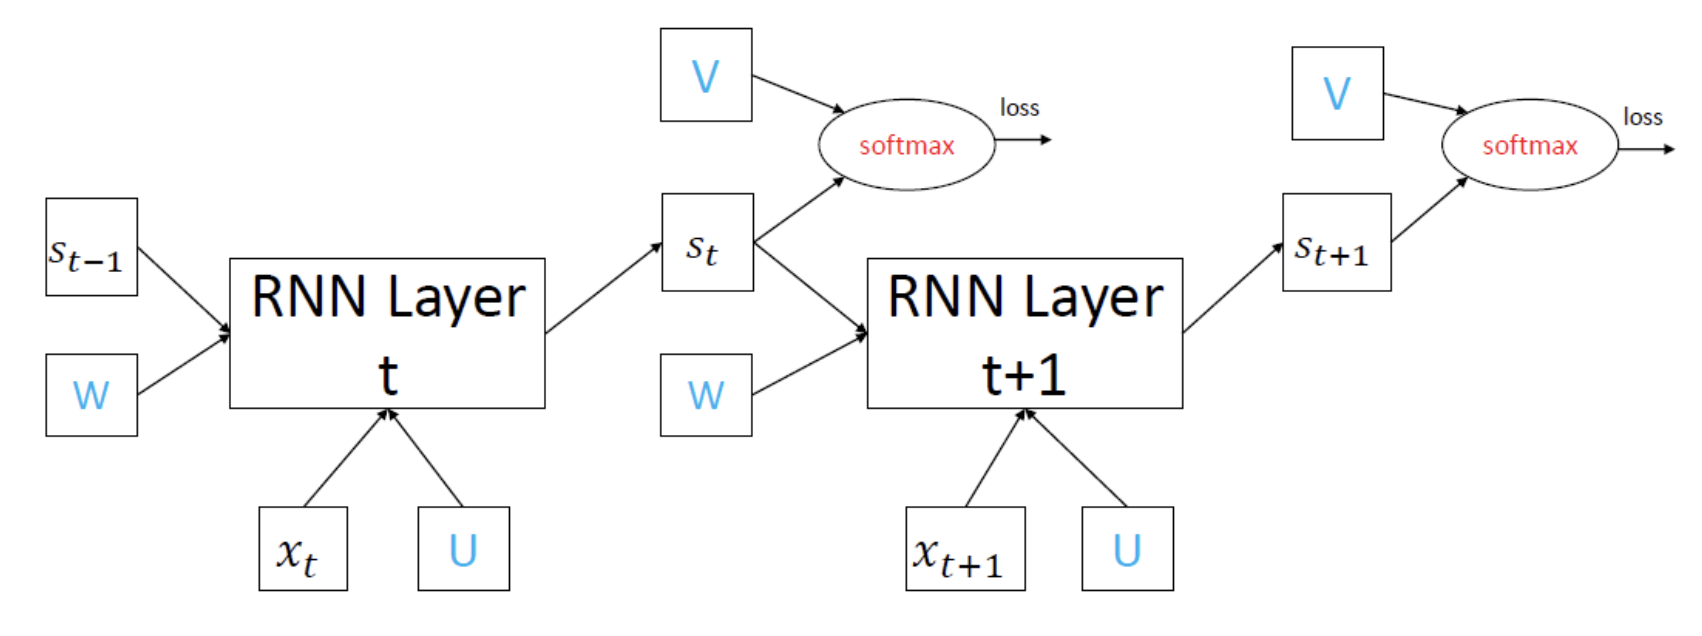

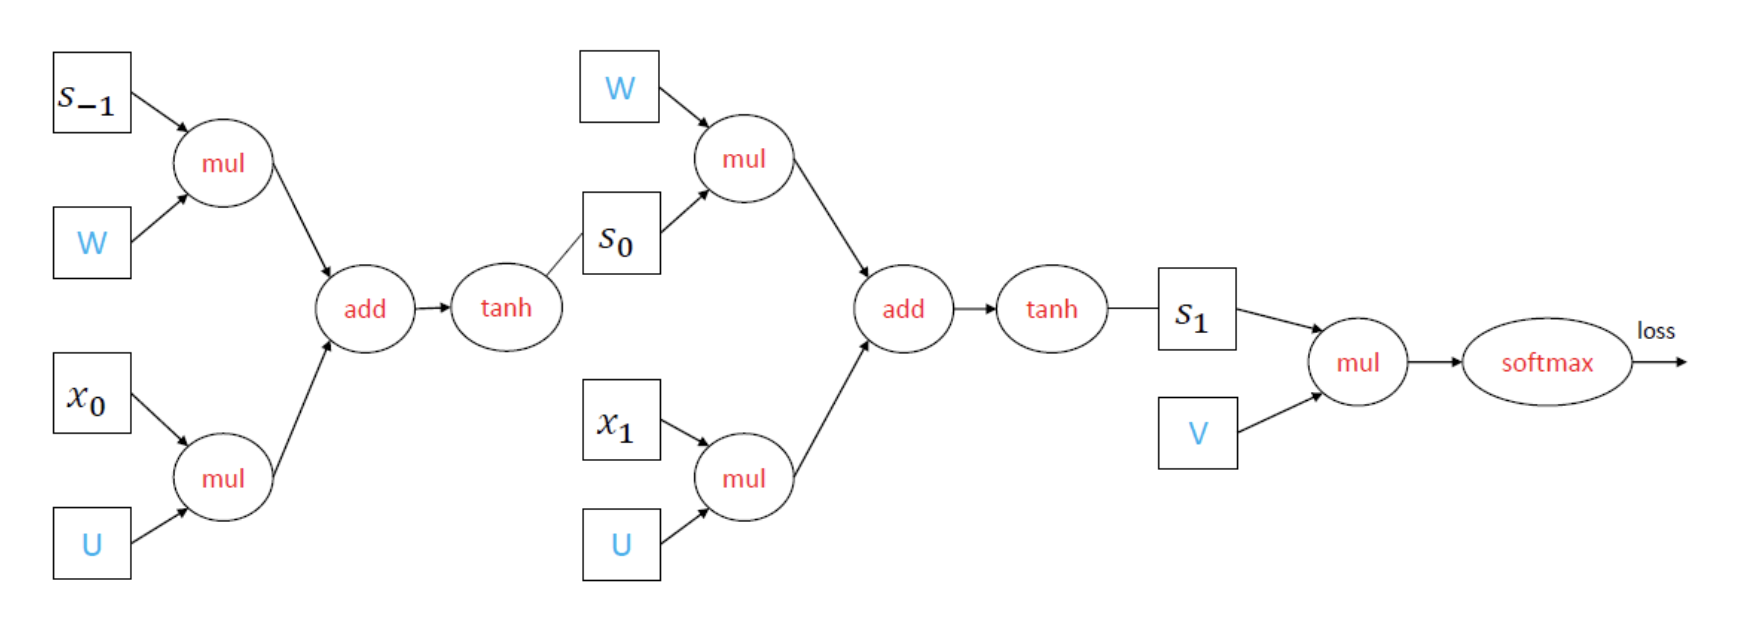

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Step 5: RNN Model Definition
class RNNModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=vocab_size, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out



In [7]:
# Step 6: Training Function with Gradient Clipping
def train_rnn(model, train_loader, val_loader, vocab_size, num_epochs=10, learning_rate=0.01, clip_value=1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)


    train_losses = []
    val_losses = []


    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for inputs, targets in train_loader:
            inputs = inputs.squeeze(-1)  # Remove the extra dimension for one-hot vectors
            targets = torch.argmax(targets.squeeze(-1), dim=-1)

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs = outputs.view(-1, vocab_size)
            targets = targets.view(-1)

            loss = criterion(outputs, targets)
            loss.backward()

            # Apply gradient clipping if specified
            if clip_value:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)


            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.squeeze(-1)
                targets = torch.argmax(targets.squeeze(-1), dim=-1)

                outputs = model(inputs)
                outputs = outputs.view(-1, vocab_size)
                targets = targets.view(-1)

                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        # Print loss every 100 epochs
        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

In [8]:
# Model Parameters
vocab_size = len(word_to_idx)
embedding_dim = 128
hidden_dim = 50
model = RNNModel(vocab_size, hidden_dim)
epochs=100
learning_rate=0.0001

In [9]:

train_losses_no_clip, val_losses_no_clip = train_rnn(model, train_loader, val_loader, vocab_size, num_epochs=epochs, learning_rate=learning_rate, clip_value=None)


Epoch [0/100], Train Loss: 1.2875, Val Loss: 1.2378
Epoch [10/100], Train Loss: 0.7685, Val Loss: 0.7552
Epoch [20/100], Train Loss: 0.5145, Val Loss: 0.5050
Epoch [30/100], Train Loss: 0.3763, Val Loss: 0.3710
Epoch [40/100], Train Loss: 0.3158, Val Loss: 0.3139
Epoch [50/100], Train Loss: 0.2823, Val Loss: 0.2821
Epoch [60/100], Train Loss: 0.2630, Val Loss: 0.2586
Epoch [70/100], Train Loss: 0.2466, Val Loss: 0.2490
Epoch [80/100], Train Loss: 0.2335, Val Loss: 0.2329
Epoch [90/100], Train Loss: 0.2199, Val Loss: 0.2216


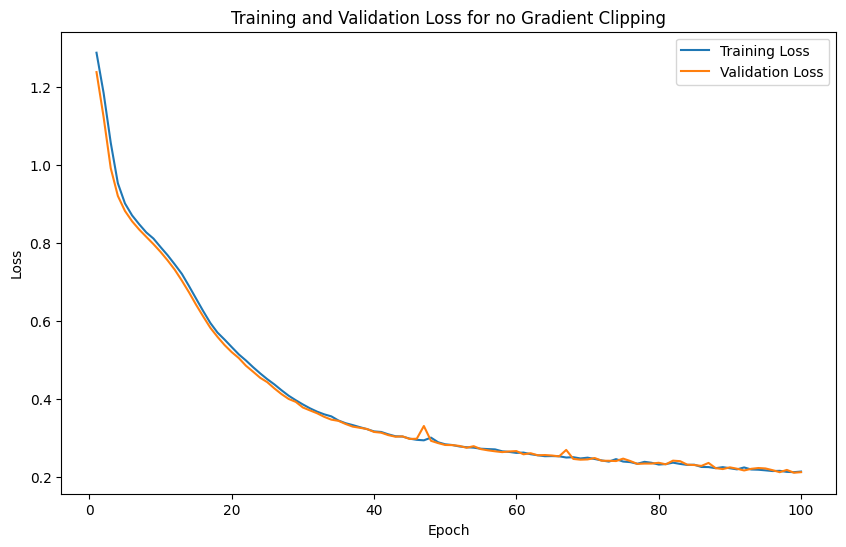

In [10]:
# Plot the training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses_no_clip, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_no_clip, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for no Gradient Clipping')
plt.legend()
plt.show()

In [11]:
epochs = 100
train_losses, val_losses = train_rnn(model, train_loader, val_loader, vocab_size, num_epochs=epochs, clip_value=0.10)

Epoch [0/100], Train Loss: 0.7813, Val Loss: 0.4131
Epoch [10/100], Train Loss: 0.1746, Val Loss: 0.1660
Epoch [20/100], Train Loss: 0.1434, Val Loss: 0.1370
Epoch [30/100], Train Loss: 0.1274, Val Loss: 0.1553
Epoch [40/100], Train Loss: 0.1380, Val Loss: 0.1322
Epoch [50/100], Train Loss: 0.1295, Val Loss: 0.1267
Epoch [60/100], Train Loss: 0.1311, Val Loss: 0.1389
Epoch [70/100], Train Loss: 0.1303, Val Loss: 0.1511
Epoch [80/100], Train Loss: 0.1276, Val Loss: 0.1338
Epoch [90/100], Train Loss: 0.1335, Val Loss: 0.1313


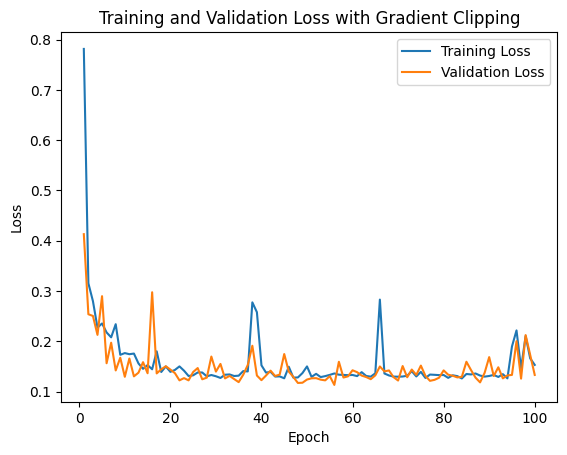

In [12]:
# Plot the training and validation losses
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Gradient Clipping')
plt.legend()
plt.show()

# Use model for inference


In [14]:
import torch

def evaluate_model(model, test_loader, vocab_size):
    """
    Evaluates the model on the test set and prints predictions for a few samples.
    """
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    criterion = nn.CrossEntropyLoss()
    predictions = []
    targets_list = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.squeeze(-1)  # Remove the extra dimension for one-hot vectors
            targets = torch.argmax(targets.squeeze(-1), dim=-1)

            outputs = model(inputs)
            outputs = outputs.view(-1, vocab_size)
            print(outputs)
            targets = targets.view(-1)

            loss = criterion(outputs, targets)
            test_loss += loss.item()

            # Generate predictions for the sequence
            preds = torch.argmax(outputs, dim=1)
            predictions.append(preds)
            targets_list.append(targets)

    avg_test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")

    # Display predictions for the first few sequences
    num_examples = min(5, len(predictions))
    for i in range(num_examples):
        print(f"\nExample {i+1}:")
        print("Predicted sequence:", [idx_to_word[idx.item()] for idx in predictions[i]])
        print("Actual sequence:   ", [idx_to_word[idx.item()] for idx in targets_list[i]])

# Load the test data into DataLoader
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

# Evaluate the model on the test set
evaluate_model(model, test_loader, vocab_size)


tensor([[  3.0952,   0.4327,  -8.4167, -11.6905],
        [ -6.1927,   1.5674,   9.0969,  -9.8581],
        [  4.5496,  -0.9980,  -6.8955, -11.6899],
        [  5.9259,  -4.1965,  -3.3908, -12.6184],
        [  7.1034,  -2.4441,  -6.7993, -10.7650],
        [  5.9229,  -4.8968,  -2.9196, -13.3648],
        [  6.2426,  -2.7506,  -6.1618, -11.6519],
        [  6.1161,  -4.3333,  -3.7418, -14.1268],
        [  6.4475,  -3.3448,  -5.9442, -11.2954],
        [  6.0556,  -4.1872,  -4.5544, -14.1283],
        [  6.6315,  -3.3838,  -5.9621, -11.7527],
        [  6.3077,  -4.3215,  -4.6071, -14.2492],
        [  6.1243,  -3.5705,  -5.1190, -11.1189],
        [  5.9114,  -4.1661,  -4.1777, -13.5762],
        [  6.6193,  -3.5776,  -5.8800, -11.6415],
        [  6.3422,  -4.2159,  -5.1016, -14.2822]])
tensor([[  3.0952,   0.4327,  -8.4167, -11.6905],
        [  1.5386,  -1.1585,  -4.8332, -15.6161],
        [  3.5982,   0.5425, -12.9630, -13.4490],
        [  2.3793,  -0.0868, -11.4994, -14.3202],

## Inferences and Conclusion : State all the key observations and conclusion

Gradient clipping helps to learn the model quickly

#**Problem 2** : Demonstrate the same for a Sine Wave

Objective : Given a sequence of 50 numbers belonging to a sine wave, predict the 51st number in the series.

In [ ]:
## Write your code here

import math

sin_wave = np.array([math.sin(x) for x in np.arange(200)])

plt.plot(sin_wave)

In [ ]:
# Prepare Data for RNN
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):

        x = data[i:i + seq_length]
        #print(x)
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
        #print("i = ", i, " y = ", y)
    return np.array(xs), np.array(ys)

# Create sequences
sequence_length = 50  # Length of input sequences
X, y = create_sequences(sin_wave, sequence_length)

# Convert to PyTorch tensors and reshape
X = torch.FloatTensor(X).unsqueeze(-1)  # Shape: (num_samples, seq_length, 1)
y = torch.FloatTensor(y).unsqueeze(-1)   # Shape: (num_samples, 1)

# Print shapes
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

In [ ]:
# Step 3: Define the RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)  # Output 1 value

    def forward(self, x):
        #print("length of x", x.shape)
        out, _ = self.rnn(x) # x has shape (batch_size, seq_length, hidden_dim)
        #print(out)
        out = self.fc(out[:, -1, :])  # Use the last time step output, out is .... All batch_size, last time step, all features
        return out

# Model parameters
input_size = 1
hidden_dim = 50
model = RNNModel(input_size, hidden_dim)
print ("==============")

# Step 4: Compile and Train the Model
criterion = nn.MSELoss() # Regression Problem
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)  # Loss calculation should work now
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Make Predictions
# Predict the next value after the last sequence
print(sequence_length)

last_sequence = sin_wave[-sequence_length:].reshape((1, sequence_length, 1))


print("last sequwnce shape", last_sequence.shape)
last_sequence_tensor = torch.FloatTensor(last_sequence)

model.eval()
with torch.no_grad():
    predicted_value = model(last_sequence_tensor)

print(f'Predicted value: {predicted_value.item():.4f}')

# Plot results
plt.plot(sin_wave, label='Original Sine Wave')
plt.scatter(len(sin_wave), predicted_value.item(), color='red', label='Predicted Value')
plt.title('Sine Wave Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# Inferences

Using Sinewave it was able predict the next sequence correctly